In [58]:
# 初始设置和导入
import os
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import h5py
import numpy as np
import re
import json
from pathlib import Path
from scipy.stats import gmean
from matplotlib.patches import Patch

print("环境设置完成")

环境设置完成


In [59]:
config = {
    "applications": [
        {"name": "SSSP", "weighted": True},
        {"name": "SSWP", "weighted": True},
        {"name": "BFS", "weighted": False},
        {"name": "CC", "weighted": False},
    ],
    "datasets": {
        "roadNet-CA-ungraph": {
            "source": 0, "direction": "-s",
        },
        "soc-LiveJournal1" : {
            "source" : 0, "direction": "",
        },
        "com-lj.ungraph" : {
            "source" : 0, "direction": "-s",
        },
        "wiki-Talk" : {
            "source" : 2, "direction" : "",
        },
        "com-orkut.ungraph" : {
            "source" : 0, "direction" : "-s",
        },
    },
    "hardware": {
        # "cores_configs": [(1, 2)],
        "cores_configs": [(16, 6)],
        "type": "ooo_nuca",
        "bank_size": 0.5 * 1024 * 1024,
    },
    "prefetch": {
        # "graphPrefetchEntries": [(4, 32), (8, 32), (16, 32), (32, 32)],
        "graphPrefetchEntries": [(4, 32)],
        "PDELatency": 2,
    },
    "paths": {
        "DATASET_ROOT":  Path("/home/xuanyi/research/graph/RisGraph") / "data",
        "ROOT": Path("/home/xuanyi/research/simulator/DAMOV/simulator"),
        "TEMPLATE_DIR": Path("/home/xuanyi/research/simulator/DAMOV/simulator/templates"),
        "FRAMEWORK_DIR" : Path("/home/xuanyi/research/graph/graphbolt/app/synthetic"),
    }
}

In [60]:
# 工具函数定义
def convert_config_to_json(js):
    """转换配置文件为JSON格式"""
    js = '{\n%s}' % js
    replacements = [
        (' = ', ' : '), (';\n', ',\n'), (r',\n(\s*)}', r'\n\1}'),
        (r'(\S+) : ', r'"\1" : '), (r'(\d+)L', r'\1')
    ]
    for pattern, repl in replacements:
        js = re.sub(pattern, repl, js)
    return js

def safe_extract(func, default=0):
    """安全提取数据的装饰器"""
    def wrapper(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception as e:
            print(f"Warning: {func.__name__} failed: {e}")
            return default
    return wrapper

import numpy as np
from functools import wraps

def safe_extract(func):
    """统一异常捕获，避免函数出错"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception:
            return 0
    return wrapper


@safe_extract
def get_execution_time(config, dataset):
    phaseLength = int(config['sim']['phaseLength'])
    phases = int(dataset[-1]['phase'])
    return int(phaseLength * (phases + 1))


@safe_extract
def get_total_load_stall_time(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['loadStallsTotal'])


@safe_extract
def get_total_graph_load_stall_time(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['graphLoadStallsTotal'])


@safe_extract
def get_graph_stall_proportion(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.min(dataset[-1][core_name]['graphLoadStallsTotal'] / dataset[-1][core_name]['loadStallsTotal'])


@safe_extract
def get_total_execution_time(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['cycles'])


@safe_extract
def get_total_hit_num(dataset, cache):
    return np.sum(dataset[-1][cache]['hGETS']) + np.sum(dataset[-1][cache]['hGETX'])


@safe_extract
def get_total_miss_num(dataset, cache):
    return (np.sum(dataset[-1][cache]['mGETS']) +
            np.sum(dataset[-1][cache]['mGETXIM']) +
            np.sum(dataset[-1][cache]['mGETXSM']))


@safe_extract
def get_total_graph_hit_num(dataset, cache):
    return np.sum(dataset[-1][cache]['hGraphGETS']) + np.sum(dataset[-1][cache]['hGraphGETX'])


@safe_extract
def get_total_graph_miss_num(dataset, cache):
    return (np.sum(dataset[-1][cache]['mGraphGETS']) +
            np.sum(dataset[-1][cache]['mGraphGETXIM']) +
            np.sum(dataset[-1][cache]['mGraphGETXSM']))


@safe_extract
def get_vertex_updated_times(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['propertyStore'])


@safe_extract
def get_data_access_nums(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['edgeLoad'])


@safe_extract
def get_average_load_latency(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.average(dataset[-1][core_name]['averageLoadLatency'])


@safe_extract
def get_average_graph_load_latency(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.min(dataset[-1][core_name]['averageGraphLoadLatency'])


@safe_extract
def get_total_graph_load_latency(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['graphDataLoadLatency'])

@safe_extract
def get_total_prefetch_stall_cycles(dataset):
    return (np.sum(dataset[-1]['graphPrefetcher']['StallCycles']))

@safe_extract
def get_effective_access_nums(filename):
    start = False
    with open(filename, 'r') as f:
        for line in f:
            if "ROI begin" in line:
                start = True
            if start and "Effective propagation number in this batch" in line:
                return float(line.split(":")[1].strip())
    return 0


print("工具函数定义完成")

工具函数定义完成


In [61]:
def parse_mcpat_energy(file_path):
    # 分类定义（提前定义好）
    categories = {
        "Core": [
            "core-core", "core-ifetch", "core-alu", "core-int",
            "core-fp", "core-mem", "core-other"
        ],
        "L1": ["icache", "dcache"],
        "L2": ["l2"],
        "LLC": ["l3"],
        "Memory": ["dram"],
    }

    energy_data = {}
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or ("energy" in line and "Energy" in line):
                    continue  # 跳过空行和表头

                parts = [p for p in line.split() if p]
                if len(parts) < 4:
                    continue

                component = parts[0]
                try:
                    energy = float(parts[3].replace('J', ''))
                except (ValueError, IndexError):
                    energy = 0.0  # 如果解析失败，设为 0
                energy_data[component] = energy

    except (FileNotFoundError, IOError):
        energy_data = {}

    # 分类能耗累加
    category_energy = {}
    for category, components in categories.items():
        total = sum(energy_data.get(comp, 0.0) for comp in components)
        category_energy[category] = total

    return category_energy

In [62]:
# 简化的数据收集函数（基于framework和hardware区分配置）
def collect_simulation_data(base_path, framework, hardware):
    """
    收集模拟数据 - 基于framework和hardware区分配置

    Parameters:
    base_path: 基础路径
    framework: 框架名称 (kickstarter)
    hardware: 硬件配置 (L1_64, stride_prefetch, graph_prefetch_4_32_2, graph_prefetch_with_filter_4_32_2)
    """
    data_records = []

    for app_config in config["applications"]:
        app_name = app_config["name"]

        for dataset_name, dataset_config in config["datasets"].items():

            for cores, mc in config["hardware"]["cores_configs"]:

                # 构建统计目录路径（与配置生成脚本完全一致）
                stat_dir = (base_path / framework / hardware / app_name /
                            dataset_name / config["hardware"]["type"] / str(cores))

                if not stat_dir.exists():
                    print(f"目录不存在: {stat_dir}")
                    continue

                try:
                    # 读取配置文件
                    cfg_file = stat_dir / 'result.out.cfg'
                    if not cfg_file.exists():
                        print(f"配置文件不存在: {cfg_file}")
                        continue

                    with open(cfg_file) as jf:
                        config_data = json.loads(convert_config_to_json(jf.read()))

                    # 读取HDF5数据
                    h5_file = stat_dir / 'result.zsim-ev.h5'
                    if not h5_file.exists():
                        print(f"HDF5文件不存在: {h5_file}")
                        continue

                    with h5py.File(h5_file, 'r') as f:
                        dataset_data = f['stats']['root']

                    # 提取所有指标
                    record = {
                        # 基础信息
                        'Framework': framework,
                        'Hardware': hardware,
                        'Application': app_name,
                        'Dataset': dataset_name,
                        'Cores': cores,
                        'MemoryControllers': mc,

                        # 执行时间相关
                        'ExecutionTime': get_execution_time(config_data, dataset_data),
                        'TotalExecutionCycles': get_total_execution_time(config_data, dataset_data),

                        # 负载相关
                        'UpdatedTimes': get_vertex_updated_times(config_data, dataset_data),
                        'AccessTimes': get_data_access_nums(config_data, dataset_data),

                        # 延迟相关
                        'AvgLoadLatency': get_average_load_latency(config_data, dataset_data),
                        'AvgGraphLoadLatency': get_average_graph_load_latency(config_data, dataset_data),
                        'TotalGraphLoadLatency': get_total_graph_load_latency(config_data, dataset_data),

                        # 停顿相关
                        'TotalLoadStall': get_total_load_stall_time(config_data, dataset_data),
                        'TotalGraphLoadStall': get_total_graph_load_stall_time(config_data, dataset_data),
                        'GraphStallProportion': get_graph_stall_proportion(config_data, dataset_data),

                        # 预取相关
                        'TotalPrefetchStallCycles': get_total_prefetch_stall_cycles(dataset_data),

                        # 能耗
                        'Energy': parse_mcpat_energy(stat_dir / "mcpat.log")
                    }

                    # 添加缓存统计
                    cache_stats = {}
                    for cache_level in ['l1d', 'l3']:
                        try:
                            total_accesses = (get_total_hit_num(dataset_data, cache_level) +
                                                get_total_miss_num(dataset_data, cache_level))
                            graph_accesses = (get_total_graph_hit_num(dataset_data, cache_level) +
                                                get_total_graph_miss_num(dataset_data, cache_level))

                            if total_accesses > 0:
                                cache_stats[f'{cache_level}_TotalMissRate'] = (
                                    get_total_miss_num(dataset_data, cache_level) / total_accesses)
                                cache_stats[f'{cache_level}_GraphMissRate'] = (
                                    get_total_graph_miss_num(dataset_data, cache_level) / graph_accesses if graph_accesses > 0 else 0)
                                cache_stats[f'{cache_level}_GraphAccessProportion'] = (
                                    graph_accesses / total_accesses)
                        except:
                            pass

                    record.update(cache_stats)

                    data_records.append(record)
                    # print(f"✓ 处理完成: {framework}/{hardware}/{app_name}/{dataset_name}")

                except Exception as e:
                    print(f"✗ 处理失败: {stat_dir} - {e}")

    return pd.DataFrame(data_records)

# 批量收集所有配置的数据
def collect_all_configurations(base_path):
    """
    收集所有配置的数据
    """
    all_data_frames = []

    # 所有配置组合
    configurations = [
        # Kickstarter 配置
        ("kickstarter", "base"),
        # ("kickstarter", "L1_64"),
        # ("kickstarter", "stride_prefetch"),
        # 预取配置
        *[("kickstarter", f"graph_prefetch_{root}_{dest}_{config['prefetch']['PDELatency']}")
          for root, dest in config['prefetch']['graphPrefetchEntries']],
        *[("kickstarter", f"graph_prefetch_with_filter_{root}_{dest}_{config['prefetch']['PDELatency']}")
          for root, dest in config['prefetch']['graphPrefetchEntries']],
    ]

    for framework, hardware in configurations:
        # print(f"开始收集 {framework}/{hardware} 数据...")
        df = collect_simulation_data(base_path, framework, hardware)
        if not df.empty:
            all_data_frames.append(df)
            # print(f"✓ 完成 {framework}/{hardware}: {len(df)} 条记录")
        # else:
            # print(f"⚠  {framework}/{hardware}: 无数据")

    if all_data_frames:
        return pd.concat(all_data_frames, ignore_index=True)
    else:
        return pd.DataFrame()

if __name__ == "__main__":
    base_dir = Path("/home/xuanyi/research/simulator/DAMOV/simulator/zsim_stats(request limited)")

    print("开始收集所有配置的数据...")
    all_data = collect_all_configurations(base_dir)

    if not all_data.empty:
        # 保存数据
        all_data.to_csv("all_simulation_results.csv", index=False)

        print("数据收集完成！")
        print(f"总共收集了 {len(all_data)} 条记录")
        print(f"包含的配置组合: {all_data[['Framework', 'Hardware']].drop_duplicates().to_string(index=False)}")
    else:
        print("没有收集到任何数据！")

开始收集所有配置的数据...
数据收集完成！
总共收集了 60 条记录
包含的配置组合:   Framework                          Hardware
kickstarter                              base
kickstarter             graph_prefetch_4_32_2
kickstarter graph_prefetch_with_filter_4_32_2


In [63]:
# ==================== 全局样式设置 ====================
# 设置统一的图表尺寸和样式
CHART_CONFIG = {
    # 基础尺寸 (以pt为单位，转换为英寸)
    'single_column_width_pt': 430,      # 单栏宽度
    'pt_to_inch': 1/72,                 # pt转英寸系数

    # 图表尺寸比例
    'height_ratio_single': 0.3,        # 单图高度比例
    'height_ratio_double': 0.26,        # 双图高度比例

    # 图表元素尺寸
    'bar_width': 0.8,                   # 柱状图宽度
    'group_gap': 1,                     # 组间间距
    'line_width': 0.5,                  # 线条宽度
    'font_sizes': {
        'title': 8,
        'axis_label': 8,
        'tick': 8,
        'legend': 8,
        'annotation': 8
    },
    'position' : {
        'annotation' : -0.3
    },
    'colors': {
        # 基础颜色
        'total': '#1f77b4',      # 深蓝色 - 总数据/基准
        'graph': '#ff7f0e',      # 橙色 - 图数据/主要对比
        'other': '#2ca02c',      # 绿色 - 其他数据

        # 扩展颜色 - 用于多个配置对比
        'config1': '#1f77b4',    # 深蓝色 (基准)
        'config2': '#ff7f0e',    # 橙色 (对比1)
        'config3': '#2ca02c',    # 绿色 (对比2)
        'config4': '#d62728',    # 红色 (对比3)
        'config5': '#9467bd',    # 紫色 (对比4)
        'config6': '#8c564b',    # 棕色 (对比5)
        'config7': '#e377c2',    # 粉色 (对比6)
        'config8': '#7f7f7f',    # 灰色 (对比7)

        # 语义颜色
        'kickstarter': '#1f77b4',       # Kickstarter - 蓝色
        'wsgraph': '#ff7f0e',           # WSGraph - 橙色
        'wsgraph_s': '#2ca02c',         # WSGraph-S - 绿色
        'prefetch': '#d62728',          # 预取配置 - 红色
        'base': '#7f7f7f',              # 基础配置 - 灰色

        # 功能颜色
        'improvement': '#2ca02c',       # 改进/优化 - 绿色
        'degradation': '#d62728',       # 性能下降 - 红色
        'neutral': '#7f7f7f',           # 中性 - 灰色

        # 图表元素颜色
        'grid': 'black',
        'grid_alpha': 1,
        'text': 'black',
        'background': 'white'
    }

}

# 计算具体尺寸
def get_figure_size(width_type='single', height_type='single'):
    """获取统一尺寸的图表大小"""
    if width_type == 'single':
        width_pt = CHART_CONFIG['single_column_width_pt']
    else:
        width_pt = CHART_CONFIG['double_column_width_pt']

    width_inch = width_pt * CHART_CONFIG['pt_to_inch']

    if height_type == 'single':
        height_inch = width_inch * CHART_CONFIG['height_ratio_single']
    else:
        height_inch = width_inch * CHART_CONFIG['height_ratio_double']

    return (width_inch, height_inch)

# 设置绘图样式
def setup_plot_style():
    plt.rcParams.update({
        # 字体设置
        'font.family': 'serif',
        'font.serif': 'Times New Roman',
        'font.style': 'normal',
        'font.size' : 8,
        'mathtext.fontset': 'stix',

        # 坐标轴设置
        'axes.edgecolor': '0.15',  # 坐标轴颜色
        'axes.linewidth': 0.8,  # 坐标轴线宽
        'axes.grid': False,  # 显示网格
        'grid.color': '0.9',  # 网格颜色
        'grid.linestyle': ':',  # 网格线型
        'grid.linewidth': 0.5,  # 网格线宽

        # 图形元素设置
        'figure.autolayout': True,  # 自动调整布局
        'figure.dpi': 100,  # 默认DPI
        'figure.facecolor': 'white',  # 图形背景色

        # 刻度设置
        'xtick.direction': 'out',  # x刻度方向
        'ytick.direction': 'out',  # y刻度方向
        'xtick.major.size': 3,  # x刻度长度
        'ytick.major.size': 3,  # y刻度长度

        # 图例设置
        'legend.frameon': True,  # 显示图例边框
        'legend.framealpha': 1,  # 图例不透明度
        'legend.edgecolor': '0.8',  # 图例边框颜色

        # 保存设置
        'savefig.dpi': 300,  # 保存图像DPI
        'savefig.bbox': 'tight',  # 保存时自动调整边界
        'savefig.pad_inches': 0.1  # 保存时内边距
    })

setup_plot_style()

# 数据集映射
dataset_mapping = {
    "roadNet-CA-ungraph": "CA",
    "soc-LiveJournal1": "SL",
    "com-lj.ungraph": "CL",
    "wiki-Talk": "WT",
    "com-orkut.ungraph": "CO",
}

shortdatasets = ['CA', 'SL', 'CL', 'WT', 'CO']
algorithms = ['SSSP', 'SSWP', 'BFS', 'CC']
components = ['Core', 'L1', 'L2', 'LLC', 'Memory']

print("绘图样式设置完成")

绘图样式设置完成


In [64]:
class GroupedBarPlotTemplate:
    """
    分组柱状图统一模板（支持多维数据，末尾单独添加 Gmean）
    """

    def __init__(self, config):
        """初始化模板配置"""
        self.config = config

    def create_grouped_plot(self, data, category_labels, group_labels, bar_labels=None,
                           colors=None, ylabel='Value', title=None, legend=("upper center", 5),
                           save_path=None, figsize_type='single',
                           add_gmean=False):
        """
        创建分组柱状图（支持多维数据，Gmean 作为最后单独一组）

        Parameters
        ----------
        data : array
            shape = (n_categories, n_groups, n_bars)
        category_labels : list
            类别标签（如算法名称）
        group_labels : list
            组标签（如数据集名称）
        bar_labels : list
            柱子标签（如数据类型）
        colors : list
            柱子颜色
        ylabel : str
            Y 轴标签
        title : str
            图标题
        save_path : str
            保存路径
        figsize_type : str
            图表大小 ('single' 或 'double')
        add_gmean : bool
            是否在最后添加整体 Gmean
        """
        # 设置默认颜色
        if colors is None:
            colors = [self.config['colors']['graph'], self.config['colors']['total']]

        if bar_labels is None:
            bar_labels = ['Data']

        # 转为 numpy
        data = np.array(data)
        n_categories = len(category_labels)
        n_groups = len(group_labels)
        n_bars = len(bar_labels)

        # 检查维度
        if data.shape != (n_categories, n_groups, n_bars):
            raise ValueError(f"数据形状 {data.shape} 与 (n_categories, n_groups, n_bars) 不匹配")

        # 图表
        fig_size = get_figure_size(figsize_type, 'grouped')
        fig, ax = plt.subplots(figsize=fig_size)

        # 参数
        bar_width = self.config['bar_width']
        group_gap = self.config['group_gap']
        category_gap = self.config['group_gap']

        # 计算 components 位置
        category_positions = []
        start_pos = 0
        for _ in range(n_categories):
            category_width = n_groups * (bar_width * n_bars + group_gap) - group_gap
            category_positions.append((start_pos, start_pos + category_width))
            start_pos += category_width + category_gap

        # 每个 bar 的位置 & ticks
        x_ticks = []
        x_tick_labels = []
        bar_positions = []  # 用于计算 xlim

        for cat_idx in range(n_categories):
            cat_start = category_positions[cat_idx][0]
            for group_idx in range(n_groups):
                group_start = cat_start + group_idx * (bar_width * n_bars + group_gap)

                # group 的 xtick （居中对齐所有 bar）
                group_center = group_start + (n_bars * bar_width) / 2 - bar_width / 2
                x_ticks.append(group_center)
                x_tick_labels.append(group_labels[group_idx])

                # 画每个 bar
                for bar_idx in range(n_bars):
                    value = data[cat_idx, group_idx, bar_idx]
                    position = group_start + bar_idx * bar_width
                    bar_positions.append(position)
                    ax.bar(position, value, bar_width,
                        color=colors[bar_idx % len(colors)],
                        edgecolor='black',
                        linewidth=self.config['line_width'],
                        alpha=0.8,
                        label=bar_labels[bar_idx] if (cat_idx == 0 and group_idx == 0) else None)

        # ====== 在最后绘制 Gmean ======
        if add_gmean:
            gmean_data = gmean(data.reshape(n_categories, -1, n_bars), axis=1)  # (n_categories, n_bars)
            gmean_values = gmean_data.mean(axis=0)  # (n_bars,)，对所有 category 再平均

            gmean_start = category_positions[-1][1] + category_gap
            gmean_positions = [gmean_start + i * bar_width for i in range(n_bars)]

            bar_positions = bar_positions + gmean_positions
            for bar_idx in range(n_bars):
                ax.bar(gmean_positions[bar_idx], gmean_values[bar_idx], bar_width,
                    color=colors[bar_idx % len(colors)],
                    edgecolor='black',
                    linewidth=self.config['line_width'],
                    alpha=0.8)

            # Gmean标签像category_labels一样显示在底部
            gmean_center = (gmean_positions[0] + gmean_positions[-1]) / 2
            ax.text(gmean_center, self.config['position']['annotation'], "Gmean",
                    ha='center', va='top',
                    transform=ax.get_xaxis_transform(),
                    fontsize=self.config['font_sizes']['annotation'],
                    fontweight='bold')

        # 设置 X 轴
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, fontsize=self.config['font_sizes']['tick'])

        # 提取所有柱子位置
        all_bar_positions = np.array(bar_positions)  # 前面所有 components/group/bar 的位置
        if add_gmean:
            all_bar_positions = np.concatenate([all_bar_positions, np.array(gmean_positions)])

        # 最左边柱子左边界，最右边柱子右边界
        x_min = all_bar_positions.min() - bar_width
        x_max = all_bar_positions.max() + bar_width

        # 设置横轴范围
        ax.set_xlim([x_min, x_max])

        # 类别标签（大类）
        for cat_idx in range(n_categories):
            cat_start, cat_end = category_positions[cat_idx]
            cat_center = (cat_start + cat_end) / 2
            ax.text(cat_center, self.config['position']['annotation'], category_labels[cat_idx],
                   ha='center', va='top', transform=ax.get_xaxis_transform(),
                   fontsize=self.config['font_sizes']['annotation'],
                   fontweight='bold')

        # 分割线
        for cat_idx in range(1, n_categories):
            divider_pos = category_positions[cat_idx][0] - category_gap
            ax.axvline(divider_pos, color='black', linestyle='--')

        # Y 轴
        ax.set_ylabel(ylabel, fontsize=self.config['font_sizes']['axis_label'])
        ax.set_ylim(0, np.max(data) * 1.2)

        # 图例
        if n_bars > 1:
            fig.legend(loc=legend[0], ncol=legend[1],
                    framealpha=1, edgecolor="black",
                    fontsize=self.config['font_sizes']['legend'])

        if title:
            ax.set_title(title, fontsize=self.config['font_sizes']['title'])

        plt.tight_layout()

        if n_bars > 1:
            plt.subplots_adjust(top=0.85)

        if save_path:
            fig.savefig(save_path, format='pdf', bbox_inches='tight')
        return fig, ax


In [65]:
def collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'),
                           compare_configs = None, normalize=True, save_path = None):
    """
    收集性能对比数据

    Parameters:
    all_data: 完整数据集
    base_config: 基准配置 (framework, hardware)
    compare_configs: 对比配置列表 [(framework, hardware), ...]

    Returns:
    base_times: 基准数组
    compare_times_list: 对比数组列表
    """

    base_framework, base_hardware = base_config
    base_times = []
    compare_times_list = [[] for _ in range(len(compare_configs))]

    # 按算法和数据集顺序收集数据
    for algorithm in algorithms:
        for dataset_full, dataset_short in dataset_mapping.items():
            if dataset_short in shortdatasets:
                # 收集基准数据
                base_data = all_data[(all_data['Framework'] == base_framework) &
                                   (all_data['Hardware'] == base_hardware) &
                                   (all_data['Application'] == algorithm) &
                                   (all_data['Dataset'] == dataset_full)]

                if not base_data.empty:
                    base_time = base_data[metric].values[0]
                    base_times.append(base_time)

                    # 收集对比数据
                    for i, (compare_framework, compare_hardware) in enumerate(compare_configs):
                        compare_data = all_data[(all_data['Framework'] == compare_framework) &
                                              (all_data['Hardware'] == compare_hardware) &
                                              (all_data['Application'] == algorithm) &
                                              (all_data['Dataset'] == dataset_full)]

                        if not compare_data.empty:
                            compare_time = compare_data[metric].values[0]
                            compare_times_list[i].append(compare_time)
                        else:
                            compare_times_list[i].append(np.nan)
                else:
                    base_times.append(np.nan)
                    for i in range(len(compare_configs)):
                        compare_times_list[i].append(np.nan)

    # 转换为numpy数组
    base_times = np.array(base_times)
    compare_times_list = [np.array(times) for times in compare_times_list]

    # === normalize 逻辑 ===
    if normalize:
        # 基准列固定为 1，对比进行归一化
        base_column = np.ones_like(base_times)
        normalized_times_list = [compare_times / base_times for compare_times in compare_times_list]
    else:
        # 使用原始执行时间（不归一化）
        base_column = base_times.copy()   # ★★★ 关键修改：基准列使用原始 base 值
        normalized_times_list = compare_times_list

    # reshape
    def reshape_data(normalized_times_list, base_column, n_categories, n_groups):
        n_bars = len(normalized_times_list) + 1
        data = np.full((n_categories, n_groups, n_bars), np.nan)

        # ★ 基准列（bar 0）
        data[:, :, 0] = base_column.reshape(n_categories, n_groups)

        # ★ 对比列
        for bar_idx, arr in enumerate(normalized_times_list):
            reshaped = arr.reshape(n_categories, n_groups)
            data[:, :, bar_idx + 1] = reshaped

        return data

    n_categories = len(algorithms)
    n_groups = len(shortdatasets)

    data = reshape_data(normalized_times_list, base_column, n_categories, n_groups)

    return data

def calculate_app_gmeans(data):
    """
    计算每个应用程序的几何平均数

    Parameters:
    data: 数据矩阵 (n_algorithms, n_datasets, n_configs)

    Returns:
    app_gmeans: 每个应用程序的几何平均数矩阵 (n_algorithms, n_configs)
    """
    n_algorithms, n_datasets, n_configs = data.shape

    app_gmeans = np.zeros((n_algorithms, n_configs))

    for alg_idx in range(n_algorithms):
        for config_idx in range(n_configs):
            # 获取该算法该配置在所有数据集上的数据
            algorithm_data = data[alg_idx, :, config_idx]

            # 移除NaN值
            valid_data = algorithm_data[~np.isnan(algorithm_data)]

            if len(valid_data) > 0:
                # 计算几何平均数
                app_gmeans[alg_idx, config_idx] = gmean(valid_data)
            else:
                app_gmeans[alg_idx, config_idx] = np.nan

    return app_gmeans

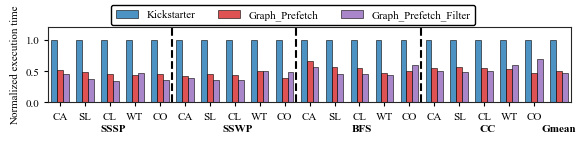

In [66]:
# 使用模板
data = collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['Kickstarter', "Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"], CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized execution time',
    add_gmean=True
)

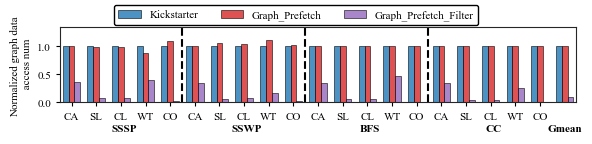

In [67]:
data = collect_normalized_data(all_data, metric="AccessTimes",  base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['Kickstarter', "Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"], CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized graph data \n access num',
    add_gmean=True,
)

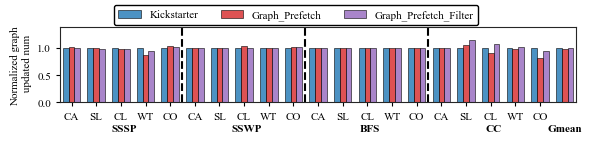

In [68]:
data = collect_normalized_data(all_data, metric="UpdatedTimes",  base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['Kickstarter', "Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"], CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized graph \n updated num',
    add_gmean=True,
)

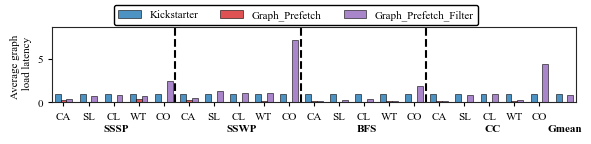

In [69]:
data = collect_normalized_data(all_data, metric="AvgGraphLoadLatency",  base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['Kickstarter', "Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"], CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
    ylabel='Average graph \n load latency',
    add_gmean=True,
)

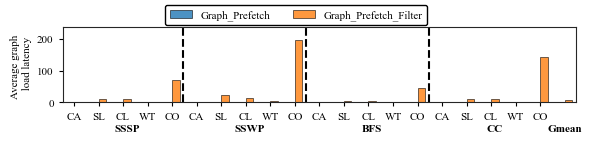

In [70]:
data = collect_normalized_data(all_data, metric="AvgGraphLoadLatency",  base_config=('kickstarter', 'graph_prefetch_4_32_2'), compare_configs=[ ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Average graph \n load latency',
    add_gmean=True,
)

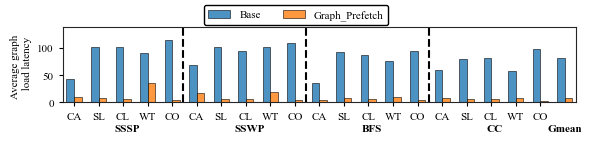

In [71]:
data = collect_normalized_data(all_data, metric="AvgGraphLoadLatency",  base_config=('kickstarter', 'base'), compare_configs=[ ('kickstarter', 'graph_prefetch_4_32_2')], normalize=False)

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["Base", "Graph_Prefetch"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Average graph \n load latency',
    add_gmean=True,
)

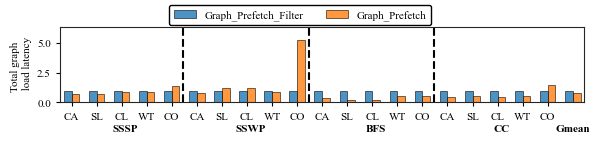

In [72]:
data1 = collect_normalized_data(all_data, metric="AvgGraphLoadLatency",  base_config=('kickstarter', 'graph_prefetch_4_32_2'), compare_configs=[ ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])

data2 = collect_normalized_data(all_data, metric="AccessTimes",  base_config=('kickstarter', 'graph_prefetch_4_32_2'), compare_configs=[ ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])

data = data1 * data2
# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["Graph_Prefetch_Filter", "Graph_Prefetch"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Total graph \n load latency',
    add_gmean=True,
)

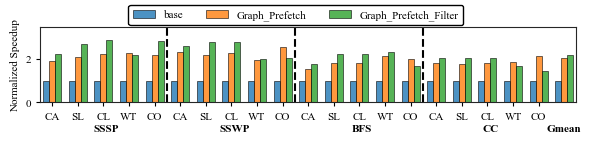

In [73]:
# 使用模板
data = collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])
data = 1 / data
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["base", "Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized Speedup',
    add_gmean=True
)

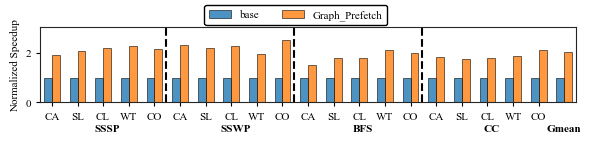

In [74]:
# 使用模板
data = collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2')])
data = 1 / data
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["base", "Graph_Prefetch"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized Speedup',
    add_gmean=True
)

ValueError: Axis limits cannot be NaN or Inf

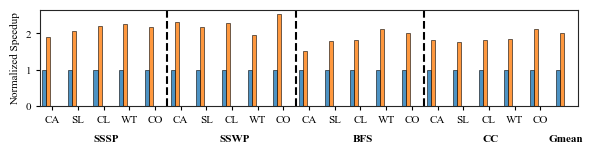

In [75]:
# 使用模板
data = collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_8_32_2'), ('kickstarter', 'graph_prefetch_16_32_2'), ('kickstarter', 'graph_prefetch_32_32_2')])
data = 1 / data
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["base", "Graph_Prefetch_4_32", "Graph_Prefetch_8_32", "Graph_Prefetch_16_32", "Graph_Prefetch_32_32"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized Speedup',
    add_gmean=True
)

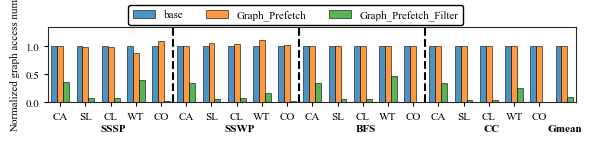

In [76]:
# 使用模板
data = collect_normalized_data(all_data, metric="AccessTimes", base_config=('kickstarter', 'base'), compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ('kickstarter', 'graph_prefetch_with_filter_4_32_2')])
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["base", "Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized graph access num',
    add_gmean=True
)

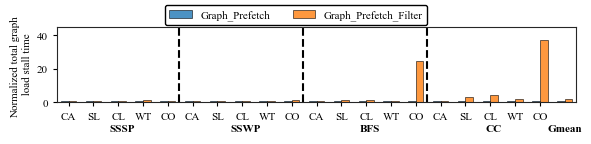

In [77]:
# 使用模板
data = collect_normalized_data(all_data, metric="TotalGraphLoadStall", base_config=('kickstarter', 'graph_prefetch_4_32_2'), compare_configs=[('kickstarter', 'graph_prefetch_with_filter_4_32_2')])
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized total graph \n load stall time',
    add_gmean=True
)

In [80]:
# 使用模板
data = collect_normalized_data(all_data, metric="TotalPrefetchStallCycles", base_config=('kickstarter', 'graph_prefetch_4_32_2'), compare_configs=[('kickstarter', 'graph_prefetch_with_filter_4_32_2')])
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=["Graph_Prefetch", "Graph_Prefetch_Filter"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"], CHART_CONFIG['colors']["config4"],CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized total graph \n load stall time',
    add_gmean=True
)

/tmp/ipykernel_3713447/1693709877.py:59: RuntimeWarning: invalid value encountered in divide
  normalized_times_list = [compare_times / base_times for compare_times in compare_times_list]


KeyboardInterrupt: 